Fitting 5 folds for each of 25 candidates, totalling 125 fits

--- XGBoost Continuous Performance ---
MAE:  10.2193
RMSE: 13.2600
R2:   0.3697

Weighted F1-Score: 0.8044

              precision    recall  f1-score   support

        Good       0.87      0.86      0.87       308
        Fair       0.62      0.64      0.63       110

    accuracy                           0.80       418
   macro avg       0.75      0.75      0.75       418
weighted avg       0.80      0.80      0.80       418



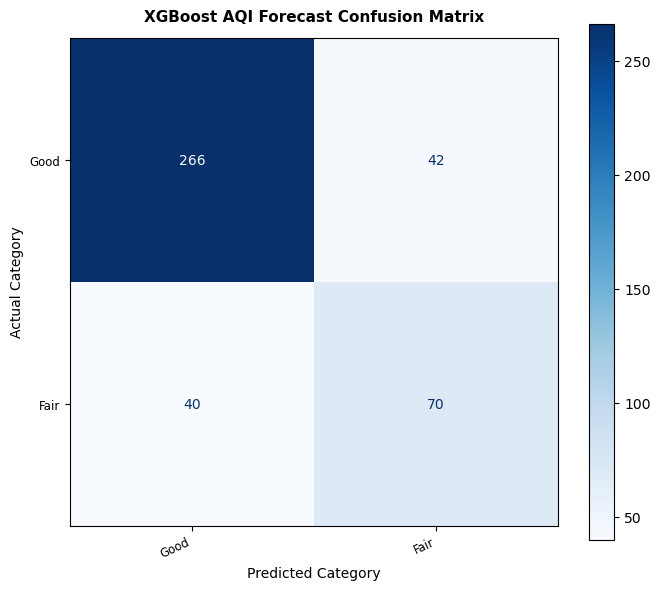

In [3]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix, 
    mean_absolute_error, r2_score, root_mean_squared_error, f1_score
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# -------------------------------------------------------------
# 1. Load Data & Prepare Sorted Time Series
# -------------------------------------------------------------
df = pd.read_csv('cleaned_pollutant_data.csv', low_memory=False)
df.rename(columns={'date': 'Date', 'aqi': 'AQI'}, inplace=True)
df = df.dropna(subset=['Date', 'AQI']).copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['sin_doy'] = np.sin(2 * np.pi * df['Date'].dt.dayofyear / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * df['Date'].dt.dayofyear / 365.25)
df['sin_dow'] = np.sin(2 * np.pi * df['Date'].dt.dayofweek / 7)
df['cos_dow'] = np.cos(2 * np.pi * df['Date'].dt.dayofweek / 7)

pollutants = ['pm2.5', 'pm10', 'so2', 'nox', 'o3', 'co']
time_features = ['sin_doy', 'cos_doy', 'sin_dow', 'cos_dow']

# -------------------------------------------------------------
# 2. Lag & Rolling Volatility Engineering (7-Day)
# -------------------------------------------------------------
FORECAST_HORIZON = 1
df['target_AQI'] = df['AQI'].shift(-FORECAST_HORIZON)

for lag in [0, 1, 2, 3]:
    df[f'aqi_lag{lag}'] = df['AQI'].shift(lag)

df['aqi_diff_1'] = df['AQI'].diff(1)
df['aqi_rolling_mean_7'] = df['AQI'].rolling(window=7).mean()
df['aqi_rolling_std_7'] = df['AQI'].rolling(window=7).std()

lag_cols = []
for p in pollutants:
    for lag in [0, 1]:
        col_name = f'{p}_lag{lag}'
        df[col_name] = df[p].shift(lag)
        lag_cols.append(col_name)

feature_cols = ['aqi_lag0', 'aqi_lag1', 'aqi_lag2', 'aqi_lag3', 'aqi_diff_1', 'aqi_rolling_mean_7', 'aqi_rolling_std_7'] + lag_cols + time_features
df = df.dropna(subset=['target_AQI', 'aqi_rolling_std_7']).reset_index(drop=True)

# -------------------------------------------------------------
# 3. Train-Test Split & Imputation
# -------------------------------------------------------------
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

train_medians = train_df[feature_cols].median()
train_df[feature_cols] = train_df[feature_cols].ffill().fillna(train_medians)
test_df[feature_cols] = test_df[feature_cols].ffill().fillna(train_medians)

X_train, y_train = train_df[feature_cols], train_df['target_AQI']
X_test, y_test = test_df[feature_cols], test_df['target_AQI']

# -------------------------------------------------------------
# 4. Hyperparameter Search
# -------------------------------------------------------------
param_distributions = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

base_xgb = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')
tscv = TimeSeriesSplit(n_splits=5)

tune_search = RandomizedSearchCV(
    estimator=base_xgb, param_distributions=param_distributions,
    n_iter=25, scoring='neg_root_mean_squared_error',
    cv=tscv, random_state=42, n_jobs=-1, verbose=1
)
tune_search.fit(X_train, y_train)
best_xgb = tune_search.best_estimator_

# -------------------------------------------------------------
# 5. Continuous Evaluation (R2 Score)
# -------------------------------------------------------------
y_pred = best_xgb.predict(X_test)
print('\n--- XGBoost Continuous Performance ---')
print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred):.4f}')
print(f'R2:   {r2_score(y_test, y_pred):.4f}') # Explicit R2 Print

# -------------------------------------------------------------
# 6. Classification & F1 Score
# -------------------------------------------------------------
CATEGORY_BINS = [-np.inf, 50, 100, 150, 200, 300, np.inf]
CATEGORY_LABELS = ['Good', 'Fair', 'Unhealthy for Sensitive Groups', 'Very Unhealthy', 'Acutely Unhealthy', 'Emergency']

y_test_cat = pd.cut(y_test, bins=CATEGORY_BINS, labels=CATEGORY_LABELS, right=True).astype(str)
y_pred_cat = pd.cut(y_pred, bins=CATEGORY_BINS, labels=CATEGORY_LABELS, right=True).astype(str)
present_labels = [label for label in CATEGORY_LABELS if (y_test_cat == label).any()]

weighted_f1 = f1_score(y_test_cat, y_pred_cat, labels=present_labels, average='weighted', zero_division=0)
print(f'\nWeighted F1-Score: {weighted_f1:.4f}\n') # Explicit F1 Print
print(classification_report(y_test_cat, y_pred_cat, labels=present_labels, zero_division=0))

# -------------------------------------------------------------
# 7. Confusion Matrix Plot
# -------------------------------------------------------------
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=present_labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('XGBoost AQI Forecast Confusion Matrix', fontsize=11, fontweight='bold', pad=12)
plt.ylabel('Actual Category', fontsize=10)
plt.xlabel('Predicted Category', fontsize=10)
plt.xticks(rotation=25, ha='right', fontsize=8.5)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.savefig('xgb_AQI_confusion_matrix.png', dpi=300)
plt.show()